# Topological Extraction: Cabárceno Graph

In this notebook, we will perform the **Spatial Data Engineering** phase. Our goal is to connect to the OpenStreetMap (OSM) Overpass API to download the internal road network of the Cabárceno Nature Park.

Mathematically, we are building a directed graph $G = (V, E)$, where:
* **V (Vertices/Nodes):** Are the intersections of the roads.
* **E (Edges):** Are the road segments. The weight of each edge $c_{ij}$ will be the actual distance in meters.

In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import os

In [2]:
# Configure OSMnx to print useful logs to the console
ox.settings.log_console = True
ox.settings.use_cache = True

# Create directories if they do not exist
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

## 1. Downloading the OSM Graph

We will use a spatial query. Cabárceno is an enclosed area, so some of its internal roads might be tagged in OSM as service or private roads. Therefore, we will use a custom filter to ensure we capture the roads used by visitor cars.

Graph downloaded. Nodes: 1930, Edges: 2679


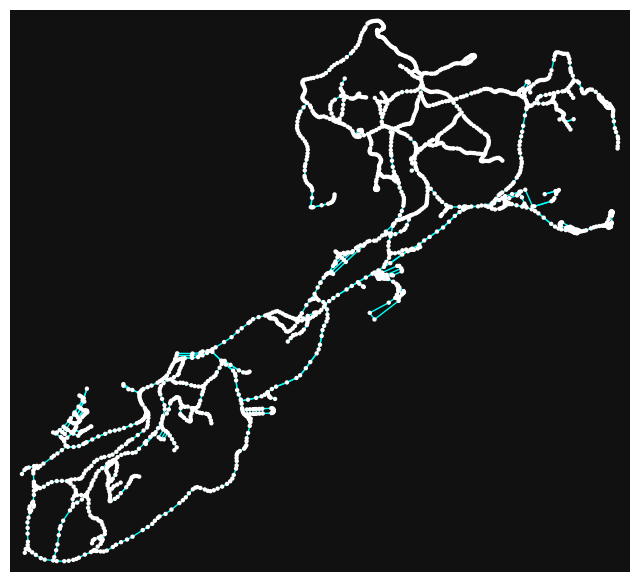

In [3]:
# Define the search area
place_name = "Parque de la Naturaleza de Cabárceno, Cantabria, Spain"

print(f"Downloading the graph for: {place_name}...")
G_raw = ox.graph_from_place(
    place_name, 
    network_type='drive', # Driveable network for cars
    custom_filter='["highway"~"service"]', # Only service roads
    simplify=False
)

print(f"Graph downloaded. Nodes: {len(G_raw.nodes)}, Edges: {len(G_raw.edges)}")

# Quick visualization of the extracted graph
fig, ax = ox.plot_graph(G_raw, node_size=10, edge_linewidth=1, bgcolor='#111111', edge_color='cyan')

## 2. Mathematical Projection (CRS)

The original graph comes in WGS84 spherical coordinates (Latitude/Longitude). To apply optimization algorithms (TSP/VRP), we need to calculate the metrics $c_{ij}$ in **actual meters**, not decimal degrees. 

We will project the graph onto a 2D Cartesian plane using the UTM (Universal Transverse Mercator) system. OSMnx will automatically detect the UTM zone for Cantabria (Zone 30N).

In [4]:
# Project the graph to UTM coordinates (in meters)
G_proj = ox.project_graph(G_raw)

# Check the coordinate systems
print("Original CRS (Degrees):", G_raw.graph['crs'])
print("Projected CRS (Meters):", G_proj.graph['crs'])

Original CRS (Degrees): epsg:4326
Projected CRS (Meters): EPSG:32630


## 3. Artifact Export

To keep the pipeline clean, we will save the projected mathematical graph in `GraphML` format (the standard for graph theory). We will also export it as GeoDataFrames so we can load them later in our interactive application if we want to draw polygons or do quick analysis.

In [5]:
# 1. Save the complete mathematical graph for the optimization engine (OR-Tools)
filepath_graphml = '../data/processed/cabarceno_graph.graphml'
ox.save_graphml(G_proj, filepath=filepath_graphml)
print(f"Graph successfully saved at: {filepath_graphml}")

# 2. Save nodes and edges as GeoDataFrames and GeoJSON for web visualization
nodes, edges = ox.graph_to_gdfs(G_proj)

filepath_nodes = '../data/processed/cabarceno_nodes.geojson'
filepath_edges = '../data/processed/cabarceno_edges.geojson'

# Remove complex columns (lists) that GeoJSON doesn't support well when exporting
cols_to_drop_edges = [col for col in edges.columns if type(edges[col].iloc[0]) == list]
edges_clean = edges.drop(columns=cols_to_drop_edges)

nodes.to_file(filepath_nodes, driver='GeoJSON')
edges_clean.to_file(filepath_edges, driver='GeoJSON')

Graph successfully saved at: ../data/processed/cabarceno_graph.graphml
